Python Prescriptive Analytics - 3/25/2026 - April Taylor

In [11]:
#Imports required
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

#Load dataset
df = pd.read_excel("C:\\Files\\Excel\\Prescriptive_PythonR\\AirbnbListings_v4.xlsx")

#Colummns converted to numeric values
cols = ["price", "minimum_nights", "number_of_reviews", "availability_365"]

#Convert selected columns to numeric (enforcing null for invalid values)
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

#Display first few rows and summary statistics
print(df.head())
print(df.describe())

                   id    host_id host_name          neighbourhood  \
0  920345000000000000  519861666  Christie              Near East   
1  915221000000000000  519861666  Christie  Near North/University   
2  913158000000000000  519861666  Christie              Near East   
3  873543000000000000  510891891       Mjm             Near South   
4  873536000000000000  510891891       Mjm             Near South   

         room_type  price  minimum_nights  number_of_reviews  availability_365  
0  Entire home/apt  316.0               1                  0               364  
1  Entire home/apt  107.0               1                  0               363  
2  Entire home/apt  117.0               1                  0               362  
3  Entire home/apt  212.0               2                  3               329  
4  Entire home/apt  174.0               2                  3               360  
                 id       host_id        price  minimum_nights  \
count  2.401000e+03  2.401000e+03

In [13]:
#Remove rows where price is missing for valid training data
df = df.dropna(subset=["price"])

#Select feature columns used for prediction
features = ["minimum_nights", "number_of_reviews", "availability_365"]

#Define feature matrix and target vector
X = df[features]
Y = df["price"]

#Initialize Random Forest regression model 
model = RandomForestRegressor(random_state=42)

#Train model on selected features and target
model.fit(X, Y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

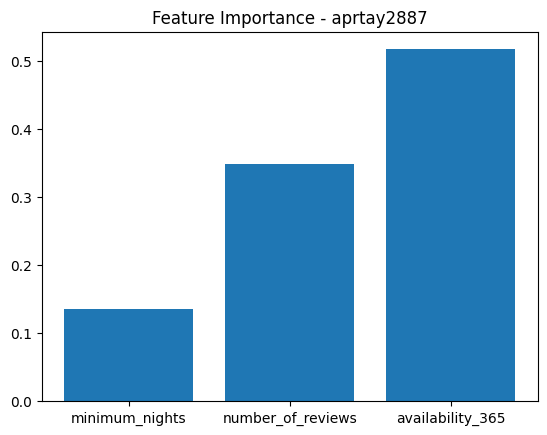

In [15]:
#Bar chart showing model's feature importance 
importances = model.feature_importances_
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

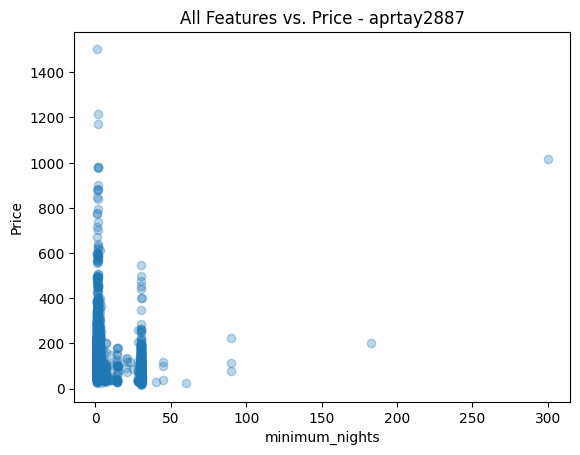

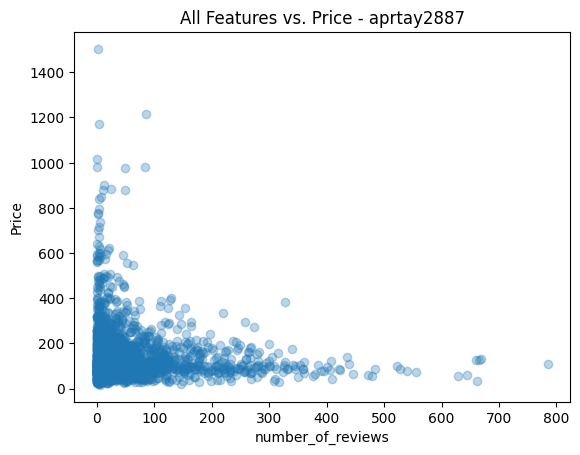

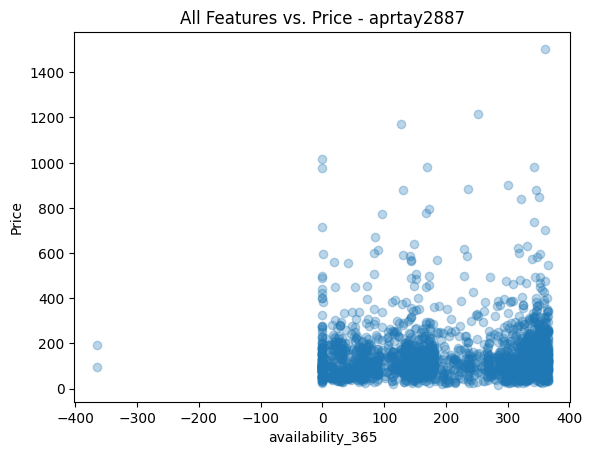

In [17]:
#Scatter plot to show how each feature relates to price
for col in features:
    plt.scatter(df[col], df["price"], alpha=0.3)
    plt.title("All Features vs. Price")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

In [20]:
#Identify the row with the highest predicted price and display results
df["predicted_price"] = model.predict(X)
best_row = df.loc[df["predicted_price"].idxmax()]
print("Optimal values:")
print(best_row[features])
print("Optimal predicted price:", best_row["predicted_price"])

Optimal values:
minimum_nights         1
number_of_reviews      2
availability_365     360
Name: 1387, dtype: object
Optimal predicted price: 1024.3147857142858


In [21]:
#Function to test how changing a feature can affect model's predicted price 
def what_if_change(feature, amount):
    temp = best_row[features].copy()
    temp[feature] += amount
    return model.predict([temp])[0]

#Display results
print("What-If: minimum_nights +14 =", what_if_change("minimum_nights", 14))
print("What-If: availability_365 +50 =", what_if_change("availability_365", 50))
print("What-If: number-of_reviews +30 =", what_if_change("number_of_reviews", 30))

C:\Users\Student\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Student\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Student\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


What-If: minimum_nights +14 = 78.4389365079365
What-If: availability_365 +50 = 112.83107142857143
What-If: number-of_reviews +30 = 109.605


In [27]:
#Function to test different feature combinations and predict prices for many scenarios
def predict_scenario(min_nights, reviews, avail):
    data = pd.DataFrame([[min_nights, reviews, avail]], columns=features)
    return model.predict(data)[0]
scenarios = [
    [7, 100, best_row["availability_365"]],
    [1, 10, best_row["availability_365"]],
    [2, best_row["number_of_reviews"], 100],
    [14, best_row["number_of_reviews"], 300],
    [best_row["minimum_nights"], 5, 300],
    [best_row["minimum_nights"], 200, 100]
]

for s in scenarios:
    print("Scenario", s, "Predicted Price:", predict_scenario(*s))
    

Scenario [7, 100, np.int64(360)] Predicted Price: 190.10460317460317
Scenario [1, 10, np.int64(360)] Predicted Price: 100.54
Scenario [2, np.int64(2), 100] Predicted Price: 251.98
Scenario [14, np.int64(2), 300] Predicted Price: 83.88
Scenario [np.int64(1), 5, 300] Predicted Price: 92.27
Scenario [np.int64(1), 200, 100] Predicted Price: 97.03
